In [1]:
import yfinance as yf
import pandas as pd

# Netflix, Inc. Common Stock (NFLX)

## Collecting data

In [2]:
# Ticker
ticker = "NFLX"

# Create a Ticker object
nflx = yf.Ticker(ticker)

In [5]:
'''Date:  from 2020-02-03 to 2020-08-03'''
'''Interval: daily data'''
data_nflx = nflx.history(start="2020-02-03", end="2020-08-03", interval="1d")

## Descriptive statistics

In [6]:
print(data_nflx.head())

                                Open       High        Low      Close  \
Date                                                                    
2020-02-03 00:00:00-05:00  34.723999  35.963001  34.627998  35.799999   
2020-02-04 00:00:00-05:00  36.099998  36.957001  35.610001  36.901001   
2020-02-05 00:00:00-05:00  37.513000  37.525002  36.230000  36.966999   
2020-02-06 00:00:00-05:00  36.959999  37.154999  36.250999  36.695000   
2020-02-07 00:00:00-05:00  36.504002  37.180000  36.356998  36.676998   

                             Volume  Dividends  Stock Splits  
Date                                                          
2020-02-03 00:00:00-05:00  66706000        0.0           0.0  
2020-02-04 00:00:00-05:00  71615000        0.0           0.0  
2020-02-05 00:00:00-05:00  64370000        0.0           0.0  
2020-02-06 00:00:00-05:00  39204000        0.0           0.0  
2020-02-07 00:00:00-05:00  43852000        0.0           0.0  


### Extract only the opening and closing price columns

In [7]:
# Extract only the opening and closing price columns
open_prices = data_nflx["Open"]
close_prices = data_nflx["Close"]

nflx_open_close = pd.DataFrame({"Date": open_prices.index, "Open": open_prices.values, "Close": close_prices.values})
nflx_open_close.reset_index(drop=True, inplace=True)
print(nflx_open_close.head())

                       Date       Open      Close
0 2020-02-03 00:00:00-05:00  34.723999  35.799999
1 2020-02-04 00:00:00-05:00  36.099998  36.901001
2 2020-02-05 00:00:00-05:00  37.513000  36.966999
3 2020-02-06 00:00:00-05:00  36.959999  36.695000
4 2020-02-07 00:00:00-05:00  36.504002  36.676998


### Extract only the closing price columns

In [8]:
# Extract only the closing price column
close_prices = data_nflx["Close"]

nflx_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
nflx_close.reset_index(drop=True, inplace=True)

print(nflx_close.head())

                       Date      Close
0 2020-02-03 00:00:00-05:00  35.799999
1 2020-02-04 00:00:00-05:00  36.901001
2 2020-02-05 00:00:00-05:00  36.966999
3 2020-02-06 00:00:00-05:00  36.695000
4 2020-02-07 00:00:00-05:00  36.676998


In [9]:
data_nflx.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,126.000000,126.000000,126.000000,126.000000,1.260000e+02,126.0,126.0
mean,41.652230,42.531008,40.857556,41.761182,8.140387e+07,0.0,0.0
std,5.315152,5.237456,5.221588,5.256114,4.150343e+07,0.0,0.0
min,30.240000,32.290001,29.025000,29.884001,3.494800e+07,0.0,0.0
25%,37.159500,38.024499,36.462501,37.126750,5.492450e+07,0.0,0.0
50%,42.069500,42.778000,41.306999,42.139999,6.976000e+07,0.0,0.0
75%,44.902249,45.474250,44.265999,44.934500,9.304200e+07,0.0,0.0
max,56.798000,57.536999,52.096001,54.873001,2.499140e+08,0.0,0.0


In [10]:
data_nflx.shape

(126, 7)

In [11]:
data_nflx.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 126 entries, 2020-02-03 00:00:00-05:00 to 2020-07-31 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          126 non-null    float64
 1   High          126 non-null    float64
 2   Low           126 non-null    float64
 3   Close         126 non-null    float64
 4   Volume        126 non-null    int64  
 5   Dividends     126 non-null    float64
 6   Stock Splits  126 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 7.9 KB


In [12]:
data_nflx.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

## KPIs

### Completeness

In [13]:
missing_values_count = data_nflx.isnull().sum()

print("Missing values per column:")
print(missing_values_count)

Missing values per column:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


In [14]:
'''1.2 Pecetange of the Missing Values'''

total_rows = len(data_nflx)

missing_info = pd.DataFrame({
    'missing_count': data_nflx.isnull().sum(),
    'missing_percentage': (data_nflx.isnull().sum() / total_rows) * 100
})

print(missing_info)

              missing_count  missing_percentage
Open                      0                 0.0
High                      0                 0.0
Low                       0                 0.0
Close                     0                 0.0
Volume                    0                 0.0
Dividends                 0                 0.0
Stock Splits              0                 0.0


### Latency

In [15]:
'''2.1 minimum and Maxmimum Close Price'''
min_close = data_nflx['Close'].min()
max_close = data_nflx['Close'].max()
print(f"Minimum Close Price: {min_close}")
print(f"Maximum Close Price: {max_close}")
print(f"Difference between Max and Min Close Price: {max_close - min_close}")

Minimum Close Price: 29.884000778198242
Maximum Close Price: 54.87300109863281
Difference between Max and Min Close Price: 24.98900032043457


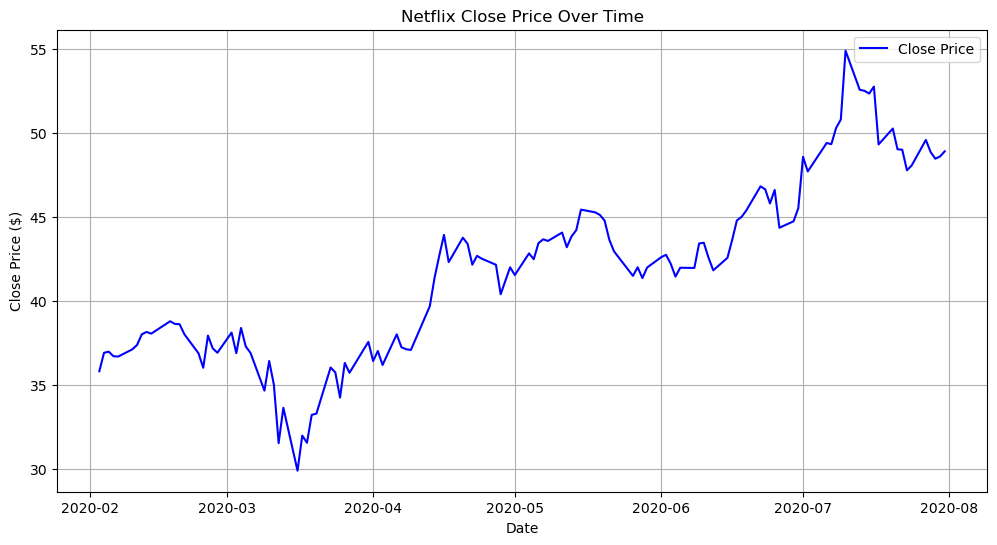

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
# Convert 'Date' column to datetime
nflx_close['Date'] = pd.to_datetime(nflx_close['Date'])


# Set 'Date' as the index 
nflx_close.set_index('Date', inplace=True)


# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(nflx_close.index, nflx_close['Close'], color='blue', label='Close Price')
plt.title('Netflix Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

### Consistency

In [17]:
print(data_nflx.dtypes)

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


In [18]:
print(data_nflx.apply(lambda x: x.map(type).nunique()))

Open            1
High            1
Low             1
Close           1
Volume          1
Dividends       1
Stock Splits    1
dtype: int64


### Error rate

In [19]:
# Missing rate
missing_rate = data_nflx.isnull().mean() * 100
print(missing_rate)

Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
dtype: float64


In [20]:
# Duplicate rate
duplicate_rate = data_nflx.duplicated().mean() * 100
print(duplicate_rate)

0.0


In [21]:
# Outliers
Q1 = data_nflx['Close'].quantile(0.25)
Q3 = data_nflx['Close'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data_nflx['Close'] < Q1 - 1.5 * IQR) | (data_nflx['Close'] > Q3 + 1.5 * IQR)).mean() * 100
print(outliers)

0.0


## ACCURACY

In [22]:
valid_close = data_nflx['Close'] > 0
valid_volume = data_nflx['Volume'] > 0
valid_dividends = data_nflx['Dividends'] >= 0

accurate_records = data_nflx[valid_close & valid_volume & valid_dividends]
data_accuracy_rate = (len(accurate_records) / len(data_nflx)) * 100
print(f"✅ Data Accuracy Rate: {data_accuracy_rate:.2f}%")

✅ Data Accuracy Rate: 100.00%


In [23]:
invalid_records = data_nflx[~(valid_close & valid_volume & valid_dividends)]
invalid_value_rate = (len(invalid_records) / len(data_nflx)) * 100
print(f"❌ Invalid Value Rate: {invalid_value_rate:.2f}%")

❌ Invalid Value Rate: 0.00%


In [24]:
duplicate_rows = data_nflx.duplicated()
duplicate_accuracy_rate = ((~duplicate_rows).sum() / len(data_nflx)) * 100
print(f"📄 Duplicate Accuracy Rate: {duplicate_accuracy_rate:.2f}%")

📄 Duplicate Accuracy Rate: 100.00%


In [25]:
unit_price_accuracy = (data_nflx['Close'] > 0).sum() / len(data_nflx) * 100
print(f"💰 Close Price Field Accuracy Rate: {unit_price_accuracy:.2f}%")

💰 Close Price Field Accuracy Rate: 100.00%
